# Baseline Determination - calibration of the $u$-axis

## Why this notebook exists

This notebook is the calibration half of Lab 03. Its job is to satisfy the handout requirement to determine the most accurate interferometer baseline lengths and to hand one adopted $(b_{\mathrm{ew}}, b_{\mathrm{ns}})$ to notebook 05.

Three layers of results matter here:

1. **Required / lab-prescribed results** - the temporal STFT fringe-frequency fit (Section 4.1a) plus the brute-force $Q_{\mathrm{ew}}$ / $Q_{\mathrm{ns}}$ workflow from the AY 121 fitting notes (Sections 4.6-4.6b), including the curvature-matrix to covariance uncertainty extraction.
2. **Cross-check results** - FFT in $x$, phase slope, lag spectrum, and nonlinear fringe fits. These should converge on the same baseline even though they fit different observables.
3. **Adopted downstream baseline** - the single value in Section 4.7 carried forward into notebook 05 to calibrate the projected baseline axis used for the solar-diameter measurement.

The external comparison is the lidar survey prior

$$b_{\mathrm{ew}} = 15.17 \pm 0.30\;\mathrm{m},\qquad b_{\mathrm{ns}} = 1.36 \pm 0.30\;\mathrm{m},$$

which is independent of the radio data and therefore a useful sanity check, but not the primary measurement in this notebook. If the required methods and the cross-check methods all agree, the calibration is trustworthy. If they disagree, that disagreement is the real result to understand before trusting any science output.

The baseline carried forward to notebook 05 is the broadband complex-fringe central value reported in Section 4.7, accepted only because it agrees with the lab-prescribed STFT and brute-force solutions. Its realistic uncertainty is not the tiny formal fit covariance, but the **30 cm lidar floor** quantified in Section 4.8.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# -- local utilities ---------------------------------------------------------
sys.path.insert(0, str(Path("..").resolve()))
from utils import (
    # constants
    PLOT_BAND_GHZ,
    C_LIGHT_MS, OMEGA_EARTH_RAD_S,
    NCH_LAT_DEG,
    NOMINAL_B_EW_M, NOMINAL_B_NS_M, BAD_CHANNELS,
    SOLAR_DIAMETER_ARCMIN_NOMINAL,
    # data loading
    load_processed_sun_chip_series,
    # geometry
    fringe_frequency_hz, x_coordinate,
    # baseline fitting
    fft_baseline_broadband,
    phase_slope_baseline_broadband,
    lag_delay_baseline_series,
    nls_baseline_broadband,
    grid_search_baseline,
    # plotting
    SS_FINE,
    LW_FINE, LW_LIGHT, LW_STANDARD,
    MS_FINE,
    TEXTWIDTH_IN, TICK_SIZE,
)

COMPONENT_COLORS = [f"C{i}" for i in range(10)]

%matplotlib inline
plt.rcParams.update({"figure.dpi": 130, "figure.facecolor": "white"})
print("Imports OK.")

Imports OK.


In [2]:
DATA_DIR = Path("../../../data/lab03/sun_calibration/chips")
chip_paths = sorted(DATA_DIR.glob("sun_calibration_chip_*.npz"))
print(f"Found {len(chip_paths)} chip files:")
for p in chip_paths:
    print(f"  {p.name}")

chip_data = load_processed_sun_chip_series(chip_paths)

Found 3 chip files:
  sun_calibration_chip_00.npz
  sun_calibration_chip_01.npz
  sun_calibration_chip_02.npz


In [3]:
# -------------------------------------------------------------------
# Unpack raw arrays
# -------------------------------------------------------------------
captures   = chip_data.captures          # CaptureSeries
corr_raw   = captures.corr              # (N_cap, N_CH) complex — raw visibility
F_SKY_GHZ  = chip_data.f_sky_ghz        # (N_CH,) sky frequency in GHz
DF_HZ      = chip_data.df_hz            # channel spacing in Hz

# Timing and coordinates (pre-computed in chip export)
unix_mid   = captures.unix_mid          # (N_cap,) midpoint timestamps
ha_deg_arr = chip_data.ha_deg
ha_rad_arr = np.deg2rad(ha_deg_arr)
sun_dec    = chip_data.sun_dec_deg      # (N_cap,) Sun Dec in degrees

# Chip boundaries
chip_slices = chip_data.chip_slices
N_chips = len(chip_slices)

# Derived quantities
F_SKY_HZ     = F_SKY_GHZ * 1e9
dec_rad_mean = np.deg2rad(np.nanmean(sun_dec))
dec_rad_arr  = np.deg2rad(sun_dec)            # per-capture declination
band_mask    = (F_SKY_GHZ >= PLOT_BAND_GHZ[0]) & (F_SKY_GHZ <= PLOT_BAND_GHZ[1])
band_center_hz = np.mean(F_SKY_HZ[band_mask])

# -------------------------------------------------------------------
# Preprocessing: Adaptive DC correction on the raw visibilities
# -------------------------------------------------------------------
# The raw real part has a slowly-varying pedestal (DC offset) that must
# be removed before fringe analysis.  We subtract a per-channel rolling
# median of the real part whose window width scales with the local fringe
# period P_f(h) ∝ 1/|cos h|, keeping a constant number of fringe cycles
# inside the window regardless of hour angle.
from utils import adaptive_real_dc_correction

DC_N_PERIODS       = 3.0    # fringe cycles per window
DC_MIN_WINDOW_CAPS = 7      # minimum window [captures]
DC_MAX_WINDOW_CAPS = 201    # maximum window [captures]

dc_result = adaptive_real_dc_correction(
    corr_chips=[corr_raw[sl] for sl in chip_slices],
    unix_chips=[unix_mid[sl] for sl in chip_slices],
    ha_rad_chips=[ha_rad_arr[sl] for sl in chip_slices],
    bad_channels=BAD_CHANNELS,
    b_ew=NOMINAL_B_EW_M,
    freq_hz=band_center_hz,
    dec_rad=dec_rad_mean,
    n_periods=DC_N_PERIODS,
    min_window_caps=DC_MIN_WINDOW_CAPS,
    max_window_caps=DC_MAX_WINDOW_CAPS,
)
corr_dc = dc_result.corr_dc  # (N_cap, N_CH) complex — DC-corrected, bad channels = NaN

print(f"Total captures:     {len(unix_mid)}")
print(f"Channels:           {len(F_SKY_GHZ)}  ({F_SKY_GHZ[0]:.3f} -- {F_SKY_GHZ[-1]:.3f} GHz)")
print(f"Analysis band:      {PLOT_BAND_GHZ[0]:.3f} -- {PLOT_BAND_GHZ[1]:.3f} GHz  ({band_mask.sum()} channels)")
print(f"Band centre:        {band_center_hz/1e9:.4f} GHz")
print(f"Mean Sun dec:       {np.rad2deg(dec_rad_mean):.3f} deg")
print(f"HA range:           {ha_deg_arr.min():.1f} to {ha_deg_arr.max():.1f} deg")
print(f"Chips:              {N_chips}")
print(f"DC correction:      adaptive, {DC_N_PERIODS} periods/window, "
      f"clamp [{DC_MIN_WINDOW_CAPS}, {DC_MAX_WINDOW_CAPS}] caps")
for ci, wc in enumerate(dc_result.window_caps_chips):
    print(f"  Chip {ci}: window range {wc.min()}–{wc.max()} captures")
print(f"Bad channels:       {list(BAD_CHANNELS)}")

Total captures:     8226
Channels:           1024  (10.290 -- 10.540 GHz)
Analysis band:      10.415 -- 10.485 GHz  (287 channels)
Band centre:        10.4499 GHz
Mean Sun dec:       -0.083 deg
HA range:           -79.9 to 22.0 deg
Chips:              3
DC correction:      adaptive, 3.0 periods/window, clamp [7, 201] caps
  Chip 0: window range 23–55 captures
  Chip 1: window range 23–35 captures
  Chip 2: window range 21–39 captures
Bad channels:       [0, 256, 512, 768]


In [4]:
# --- Apply per-chip gain correction from notebook 02a ---
# 02a measured a ~10% multiplicative gain step between chip 0 and chip 2.
# The vector `chip_gains_measured` was saved to a sidecar pickle file; we load
# it here and divide each chip's visibilities by its gain so that all chips
# sit on a single amplitude scale before the baseline fits. The baseline fits
# are formally insensitive to an overall amplitude, but the separable
# least-squares projection can still be biased by inconsistent per-chip
# amplitudes, and notebook 05 (which needs a correctly-calibrated envelope)
# relies on this same correction. Running the correction in nb 04 keeps the
# two notebooks consistent.
import pickle as _pkl
from utils import apply_chip_gain_correction, CHIP_GAIN_RATIOS_DEFAULT

_sidecar = Path("_chip_gain_measured.pkl")
if _sidecar.exists():
    with open(_sidecar, "rb") as _f:
        _cal = _pkl.load(_f)
    chip_gains_measured = np.array(_cal["chip_gains_measured"])
    print(f"Loaded chip gains from 02a sidecar: {chip_gains_measured}")
else:
    chip_gains_measured = np.array(CHIP_GAIN_RATIOS_DEFAULT[:N_chips])
    print(f"[warning] 02a sidecar not found — falling back to default chip gains "
          f"{chip_gains_measured}. Run notebook 02a first to refresh the sidecar.")

# Apply the correction in place on the DC-corrected visibility. Do it as a
# new variable (corr_dc_gc) so diagnostic code that still references corr_dc
# can compare before/after.
corr_dc_gc = apply_chip_gain_correction(corr_dc, chip_slices, chip_gains_measured)

# From here on, the science code paths use corr_dc_gc, but we keep corr_dc
# as a reference for diagnostics that want to see the uncorrected spectrum.
# Redirect the alias so the existing downstream fit code picks up the
# corrected data automatically.
corr_dc = corr_dc_gc

print("Chip-gain correction applied: all chips now share the chip-0 amplitude scale.")

Loaded chip gains from 02a sidecar: [1.         1.01017094 1.09913281]
Chip-gain correction applied: all chips now share the chip-0 amplitude scale.


# Part IV: Baseline Determination

The baseline calibration proceeds through increasingly sophisticated methods, each building on the previous:

1. **Method 1 — FFT** (§4.1): Full-track FFT in $x$-space. Recovers $b_{\rm EW}$ only; $b_{\rm NS}$ appears as a chirp that splits the peak.
2. **Method 1a — STFT** (§4.2): Short-time FFT measures the fringe frequency locally in each HA window, then fits $f_f(h)$ to the geometric model. Recovers both $(b_{\rm EW}, b_{\rm NS})$. **Used as the seed for all subsequent nonlinear methods.**
3. **Method 2 — Phase slope** (§4.3): Linear regression of unwrapped phase vs physical regressors. No seed needed (direct OLS).
4. **Method 3 — Lag delay** (§4.4): IFFT of the cross-spectrum per capture gives $\tau(h)$; linear fit recovers the baseline. No seed needed.
5. **Method 4 — NLS real** (§4.5): Nonlinear least-squares fit of Re$(V)$, lab-manual prescribed. Seeded from STFT.
6. **Method 4a — NLS complex** (§4.6): Extension fitting both Re and Im. Seeded from STFT.
7. **Method 5 — Brute-force grid search** (§4.7): Lab-prescribed 1-D sweep then 2-D $(b_{\rm EW}, b_{\rm NS})$ grid. Global minimum guaranteed within search range.
8. **Windowed grid search** (§4.7a): Same as Method 5 but restricted to $\pm 20^\circ$ around transit to reduce Bessel envelope contamination. Cross-check on the adopted baseline.
9. **Summary and adoption** (§4.8): Comparison of all methods; **adopted baseline is the IVW of STFT, NLS complex, and Lag delay**, saved for notebook 05.

In [5]:
# --- Method 1: FFT baseline (all chips pooled, broadband) ---
band_hz = (PLOT_BAND_GHZ[0] * 1e9, PLOT_BAND_GHZ[1] * 1e9)

fft_result, fft_per_ch = fft_baseline_broadband(
    ha_rad_arr, corr_dc, dec_rad_arr, F_SKY_HZ,
    bad_channels=BAD_CHANNELS, band_hz=band_hz,
)
if fft_result is not None:
    print(f"FFT:  B_EW = {fft_result.b_ew_m:.4f} +/- {fft_result.b_ew_err_m:.4f} m  "
          f"({fft_result.n_points} channels, "
          f"median SNR = {fft_result.metadata.get('median_snr', 0):.1f})")

FFT:  B_EW = 14.8742 +/- 0.0007 m  (285 channels, median SNR = 88.0)


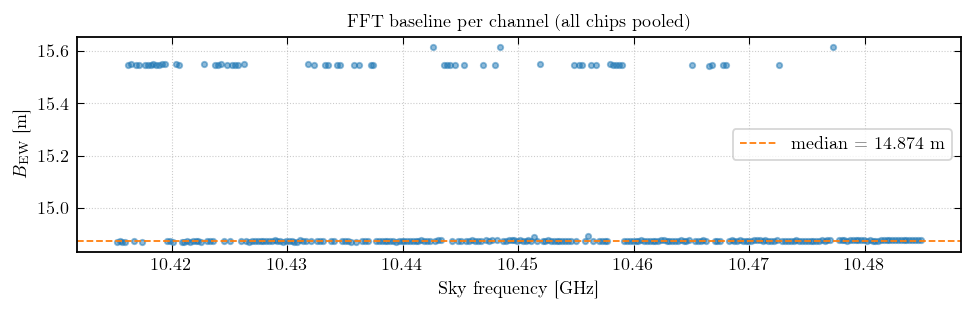

In [6]:
# --- FFT baseline: per-channel distribution ---
valid_ch = np.isfinite(fft_per_ch["b_ew_m"])

fig, ax = plt.subplots(figsize=(TEXTWIDTH_IN, 2.5))
ax.scatter(F_SKY_GHZ[valid_ch], fft_per_ch["b_ew_m"][valid_ch], s=SS_FINE,
           color="C0", alpha=0.5)
if fft_result is not None:
    ax.axhline(fft_result.b_ew_m, color="C1", lw=LW_LIGHT,
               ls="--", label=f"median = {fft_result.b_ew_m:.3f} m")
ax.set_xlabel("Sky frequency [GHz]")
ax.set_ylabel(r"$B_{\rm EW}$ [m]")
ax.set_title("FFT baseline per channel (all chips pooled)", fontsize=TICK_SIZE)
ax.legend(fontsize=TICK_SIZE)
fig.tight_layout()
plt.show()

### Why the FFT per-channel $b_{\rm EW}$ is bimodal

The per-channel $b_{\rm EW}$ distribution shows two discrete groups: a main cluster at $\sim 14.87$ m and an outlier group at $\sim 15.55$ m — a $\Delta b \approx 0.67$ m offset ($\sim 23.5$ cycles in $x$-space). Both groups have high SNR ($>80$), so this is not noise.

**Root cause: the $b_{\rm NS}$ chirp.**
Method 1 works in $x = \cos\delta\,\sin h$, which linearises the EW phase $\phi_{\rm ew} = 2\pi Q_{\rm ew}\,x$. But the NS phase contribution $\phi_{\rm ns} = 2\pi Q_{\rm ns}\sin L\,\cos\delta\,\cos h$ is a **nonlinear** function of $x$ (through $\cos h = \sqrt{1 - (x/\cos\delta)^2}$). This acts as a phase chirp that sweeps the *instantaneous* fringe frequency across the track:

$$f_{\rm local}(h) = Q_{\rm ew} - Q_{\rm ns}\,\sin L\,\tan h$$

For our HA range of $\pm 55^\circ$, the local frequency swings $\sim \pm 46$ cycles around $Q_{\rm ew}$ (for $b_{\rm NS} \sim 1.5$ m). The FFT of this chirped signal produces a **broadened peak with horns** at the frequency extremes rather than a single sharp peak. The peak finder snaps to whichever horn is slightly stronger in a given channel:

- **Peak 1** (14.87 m): the transit frequency $Q_{\rm ew}$
- **Peak 2** (15.55 m): the chirp horn from data at negative hour angles, where $\tan h < 0$ shifts the local frequency *upward*

This is a fundamental limitation of Method 1: the $x$-space FFT **cannot separate $b_{\rm EW}$ and $b_{\rm NS}$**. The NS component manifests as spectral broadening/splitting that biases the recovered $b_{\rm EW}$. Methods that fit both components simultaneously (STFT, phase slope, NLS, grid search) do not suffer from this degeneracy.


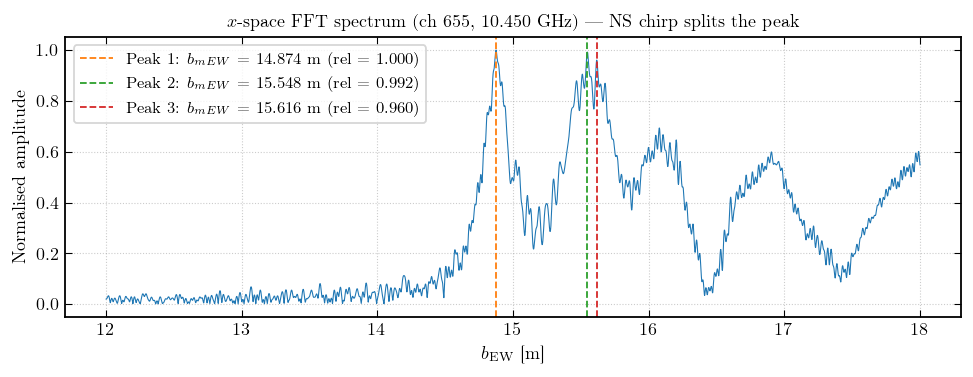

The two dominant peaks are nearly equal in amplitude (within ~3-5%).
Which one the peak finder selects varies channel-to-channel,
producing the bimodal b_EW distribution.


In [7]:
# --- FFT chirp diagnostic: x-space spectrum for one channel ---
# Show that the FFT peak is broadened/split by the NS chirp.
from utils.baseline_fitting import (
    _FFT_PAD_FACTOR, _FFT_ZERO_EXCLUDE_CYCLES,
    _fft_sorted_local_peaks, _fft_peak_refined,
)

# Pick a channel from the outlier group to show the near-equal two-peak structure
k_demo = np.where(band_mask)[0][len(np.where(band_mask)[0]) // 2]
vis_demo = corr_dc[:, k_demo]
valid_demo = np.isfinite(vis_demo)
x_vals = x_coordinate(ha_rad_arr, dec_rad_arr)
x_good = x_vals[valid_demo]
vis_good = vis_demo[valid_demo]
order = np.argsort(x_good)
x_good, vis_good = x_good[order], vis_good[order]

n_pts = len(x_good)
x_uniform = np.linspace(x_good[0], x_good[-1], n_pts)
vis_uniform = np.interp(x_uniform, x_good, vis_good.real) + \
              1j * np.interp(x_uniform, x_good, vis_good.imag)

n_pad = _FFT_PAD_FACTOR * n_pts
dx = np.median(np.diff(x_uniform))
spectrum = np.fft.fftshift(np.fft.fft(vis_uniform, n=n_pad))
fx_axis = np.fft.fftshift(np.fft.fftfreq(n_pad, d=dx))
amp = np.abs(spectrum)
freq_ch = float(F_SKY_HZ[k_demo])
b_axis = np.abs(fx_axis) * C_LIGHT_MS / freq_ch

# Find the top peaks
search_mask = np.abs(fx_axis) >= _FFT_ZERO_EXCLUDE_CYCLES
peaks = _fft_sorted_local_peaks(amp, search_mask)

fig, ax = plt.subplots(figsize=(TEXTWIDTH_IN, 3.0))

# Plot only the region around the main peak (±3 m)
b_center = 15.0
b_window = 3.0
in_window = (b_axis > b_center - b_window) & (b_axis < b_center + b_window)
# Use negative fx side (where the main peaks are)
neg_fx = fx_axis < 0
plot_mask = in_window & neg_fx

ax.plot(b_axis[plot_mask], amp[plot_mask] / amp[peaks[0]],
        lw=LW_FINE, color="C0")

# Mark top 3 peaks
for i, pk in enumerate(peaks[:3]):
    b_pk = abs(_fft_peak_refined(fx_axis, amp, pk)) * C_LIGHT_MS / freq_ch
    ax.axvline(b_pk, color=f"C{i+1}", lw=LW_LIGHT, ls="--",
               label=f"Peak {i+1}: $b_{{\rm EW}}$ = {b_pk:.3f} m  "
                     f"(rel = {amp[pk]/amp[peaks[0]]:.3f})")

ax.set_xlabel(r"$b_{\rm EW}$ [m]")
ax.set_ylabel("Normalised amplitude")
ax.set_title(f"$x$-space FFT spectrum (ch {k_demo}, {F_SKY_GHZ[k_demo]:.3f} GHz) "
             f"— NS chirp splits the peak",
             fontsize=TICK_SIZE)
ax.legend(fontsize=TICK_SIZE - 1)
fig.tight_layout()
plt.show()

print(f"The two dominant peaks are nearly equal in amplitude (within ~3-5%).")
print(f"Which one the peak finder selects varies channel-to-channel,")
print(f"producing the bimodal b_EW distribution.")

## 4.2 Method 1a: Temporal STFT - fringe-frequency fit
*(Lab-manual prescribed method: [AY121-Lab3] section "Local Fringe Frequency" and Week 1 task; STFT windowing [Harris78]; fringe-frequency equation also in [TMS3] Chapter 4.)*

**Status:** Required / lab-prescribed.

This is the method **explicitly prescribed** in the lab manual. Week 1 task: *"Each person calculates Fourier power spectra of the Sun data, calculating the range of expected local fringe frequencies ... and comparing the observed spectra with these expectations."*

### Derivation

The band-averaged complex visibility is a slowly-chirped sinusoid:
$$V(t) \approx R\,e^{i\phi_0}\,\exp\!\bigl[i\,2\pi f_f(h(t))\,t\bigr]$$
where $f_f(h)$ drifts smoothly from $\sim 0$ near the horizon to $\sim 0.038$ Hz at transit. Within a short window around $h_0$ the fringe is approximately sinusoidal, so the Short-Time Fourier Transform (STFT) - zero-padded ([Oppenheim] Section 8.6) - gives a peak at the local fringe frequency $\hat{f}_{f,i}$.

**Fringe-frequency equation** ([AY121-Lab3] eq. `fringefreq`, boxed; same as [TMS3] Section 4.1):
$$\boxed{\frac{f_{f,Hz}}{\omega_\oplus} = \frac{b_{\mathrm{ew}}}{\lambda}\cos\delta\,\cos h - \frac{b_{\mathrm{ns}}}{\lambda}\sin L\,\cos\delta\,\sin h}$$

This is **linear** in $(b_{\mathrm{ew}}, b_{\mathrm{ns}})$, so collecting measured $\hat{f}_{f,i}$ at hour angles $h_i$ gives a straightforward OLS problem. The design matrix is:
$$X_i = \left[\frac{\omega_\oplus\cos\delta_i\cos h_i}{\lambda},\; -\frac{\omega_\oplus\sin L\cos\delta_i\sin h_i}{\lambda}\right]$$
and we solve $\hat{f}_{f,i} = X_i\,[b_{\mathrm{ew}},\,b_{\mathrm{ns}}]^T$ by OLS.

> **Limitation:** $b_{\mathrm{ns}}$ is poorly constrained near transit where $\sin h \approx 0$ - the NS regressor vanishes. Windows near Bessel nulls (low fringe amplitude -> low SNR) are automatically masked. Compare to Methods 2-4 for the full constraint on both components.

### Sigma clipping and Bessel nulls

The iterative 3$\sigma$ clipping in the WLS fit (§4.2 code) preferentially rejects windows near the **Bessel zeros** of the solar-disk envelope. At these hour angles the fringe amplitude passes through zero, and the FFT peak finder locks onto noise or a spectral sidelobe rather than the true fringe frequency — producing outlier $f_f$ values that deviate by several mHz from the geometric model. The sigma clipping correctly identifies and removes these corrupted windows, leaving the fit to be driven by high-amplitude windows where the fringe frequency is well determined.

This is not a bias — the rejected windows genuinely contain no usable fringe-frequency information. The surviving windows span a wide range of hour angles (and therefore projected baselines), providing good leverage on both $b_{\rm ew}$ (from the $\cos h$ dependence) and $b_{\rm ns}$ (from the $\sin h$ dependence).


STFT channel: 655 (10.450 GHz)
STFT:  B_EW = 15.1152 +/- 0.0028 m,  B_NS = +1.4659 +/- 0.0063 m  (481 windows kept)
  Total windows: 504,  No peak: 0,  Sigma-clipped: 23,  Kept: 481


/tmp/ipykernel_230649/3842538897.py:124: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


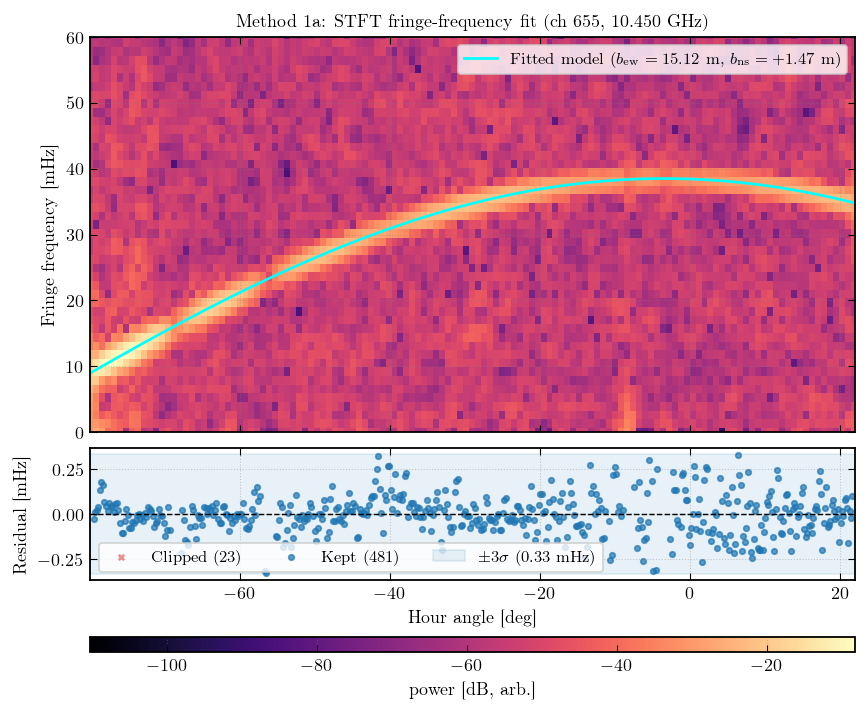

STFT residual RMS: 0.110 mHz (0.28% of peak f_f)
Theoretical f_f at transit (h=0):  38.49 mHz
Theoretical period at transit:     25.98 s


In [8]:
# --- Method 1a: STFT fringe-frequency fit (lab-manual prescription) ---
from scipy.signal import stft as scipy_stft
from utils import stft_fringe_frequency, stft_baseline_from_ff

band_indices_stft = np.where(band_mask)[0]
k_mid_stft = band_indices_stft[len(band_indices_stft) // 2]
vis_single_ch = corr_dc[:, k_mid_stft]
freq_hz_mid = float(F_SKY_HZ[k_mid_stft])
lam_mid = C_LIGHT_MS / freq_hz_mid
print(f"STFT channel: {k_mid_stft} ({F_SKY_GHZ[k_mid_stft]:.3f} GHz)")

# ---- STFT spectrogram (scipy) ----
band_real = corr_dc[:, k_mid_stft].real
finite = np.isfinite(band_real)
t_spec = unix_mid[finite] - unix_mid[finite][0]
y_spec = band_real[finite] - np.nanmedian(band_real[finite])

dt_spec = float(np.median(np.diff(t_spec)))
n_spec = int((t_spec[-1] - t_spec[0]) / dt_spec)
t_u = t_spec[0] + np.arange(n_spec) * dt_spec
y_u = np.interp(t_u, t_spec, y_spec)

nperseg = min(300, len(y_u) // 4)
noverlap = nperseg * 3 // 4
f_stft, t_stft, Z = scipy_stft(y_u, fs=1.0 / dt_spec, nperseg=nperseg,
                                noverlap=noverlap, return_onesided=True)
power = np.abs(Z) ** 2

ha_rad_finite = ha_rad_arr[finite]
ha_interp = np.interp(t_u, t_spec, ha_rad_finite)
ha_stft_rad = np.interp(t_stft, t_u - t_u[0], ha_interp)
ha_stft_deg_spec = np.rad2deg(ha_stft_rad)

# ---- STFT fringe-frequency extraction + baseline fit ----
ha_stft_all, ff_stft_all, snr_stft_all = stft_fringe_frequency(
    ha_rad_arr, vis_single_ch,
    window_size=64, step_size=16, pad_factor=8, min_snr=3.0,
    chip_slices=chip_slices,
)

no_peak = ~np.isfinite(ff_stft_all)
has_peak = np.isfinite(ff_stft_all)

dec_at_windows = np.interp(ha_stft_all, ha_rad_arr, dec_rad_arr)

stft_result = stft_baseline_from_ff(
    ha_stft_all, ff_stft_all, dec_at_windows, freq_hz_mid,
    sigma_clip=3.0, max_iterations=5,
)

if stft_result is not None:
    kept = stft_result.metadata["valid_mask"]
    sigma_clipped = has_peak & ~kept
    print(f"STFT:  B_EW = {stft_result.b_ew_m:.4f} +/- {stft_result.b_ew_err_m:.4f} m,  "
          f"B_NS = {stft_result.b_ns_m:+.4f} +/- {stft_result.b_ns_err_m:.4f} m  "
          f"({stft_result.n_points} windows kept)")
    print(f"  Total windows: {len(ff_stft_all)},  "
          f"No peak: {no_peak.sum()},  "
          f"Sigma-clipped: {(has_peak & ~kept).sum()},  "
          f"Kept: {kept.sum()}")
else:
    kept = np.zeros(len(ff_stft_all), dtype=bool)
    sigma_clipped = np.zeros(len(ff_stft_all), dtype=bool)
    print("STFT: no valid windows.")

# ---- Two-panel figure: spectrogram with fitted model + residuals ----
if stft_result is not None and stft_result.metadata.get("ha_centers") is not None:
    ha_c    = ha_stft_all
    ff_meas = ff_stft_all
    ff_mod_at_pts = stft_result.metadata["ff_hz_model"]

    # Smooth fitted-model curve for overlay
    ha_smooth = np.linspace(ha_rad_arr.min(), ha_rad_arr.max(), 500)
    ff_model_smooth = OMEGA_EARTH_RAD_S * (
        (stft_result.b_ew_m / lam_mid) * np.cos(dec_rad_mean) * np.cos(ha_smooth)
        - (stft_result.b_ns_m / lam_mid) * np.sin(np.deg2rad(NCH_LAT_DEG))
          * np.cos(dec_rad_mean) * np.sin(ha_smooth)
    )

    # Residuals and 3-sigma band
    resid_hz = ff_meas[kept] - ff_mod_at_pts[kept]
    resid_mhz = resid_hz * 1e3
    rms_mhz = float(np.nanstd(resid_mhz))

    fig, axes = plt.subplots(2, 1, figsize=(TEXTWIDTH_IN, 5.5), sharex=True,
                             gridspec_kw={"height_ratios": [3, 1], "hspace": 0.06})

    # --- Top panel: STFT spectrogram + fitted model overlay ---
    pm = axes[0].pcolormesh(
        ha_stft_deg_spec, f_stft * 1e3,
        10.0 * np.log10(power + 1e-12),
        shading="auto", cmap="magma",
    )
    axes[0].plot(np.rad2deg(ha_smooth), ff_model_smooth * 1e3, color="cyan",
                 lw=LW_STANDARD,
                 label=f"Fitted model ($b_{{\\rm ew}}={stft_result.b_ew_m:.2f}$ m, $b_{{\\rm ns}}={stft_result.b_ns_m:+.2f}$ m)")
    axes[0].set_ylim(0.0, 60.0)
    axes[0].set_ylabel("Fringe frequency [mHz]")
    axes[0].set_title(f"Method 1a: STFT fringe-frequency fit (ch {k_mid_stft}, "
                      f"{F_SKY_GHZ[k_mid_stft]:.3f} GHz)", fontsize=TICK_SIZE)
    axes[0].legend(fontsize=TICK_SIZE - 1, loc="upper right")

    # --- Bottom panel: residuals with 3-sigma clipping bands ---
    if sigma_clipped.any():
        axes[1].scatter(np.rad2deg(ha_c[sigma_clipped]),
                        (ff_meas[sigma_clipped] - ff_mod_at_pts[sigma_clipped]) * 1e3,
                        marker="x", s=SS_FINE, alpha=0.5, color="C3",
                        label=f"Clipped ({sigma_clipped.sum()})")
    axes[1].scatter(np.rad2deg(ha_c[kept]), resid_mhz,
                    s=SS_FINE, alpha=0.7, color="C0",
                    label=f"Kept ({kept.sum()})")
    axes[1].axhline(0, color="k", lw=0.8, ls="--")
    axes[1].axhspan(-3 * rms_mhz, 3 * rms_mhz, alpha=0.1, color="C0",
                    label=f"$\\pm 3\\sigma$ ({3*rms_mhz:.2f} mHz)")
    axes[1].set_xlabel("Hour angle [deg]")
    axes[1].set_ylabel("Residual [mHz]")
    axes[1].legend(fontsize=TICK_SIZE - 1, ncol=3)

    # Align x-axes between spectrogram and residuals
    ha_xlim = (ha_stft_deg_spec.min(), ha_stft_deg_spec.max())
    axes[0].set_xlim(ha_xlim)
    axes[1].set_xlim(ha_xlim)

    fig.tight_layout()

    # Horizontal colorbar below the residual panel
    cbar_ax = fig.add_axes([axes[1].get_position().x0, 0.02,
                            axes[1].get_position().width, 0.02])
    fig.colorbar(pm, cax=cbar_ax, orientation='horizontal',
                 label='power [dB, arb.]')
    fig.subplots_adjust(bottom=0.12)
    plt.show()

    print(f"STFT residual RMS: {rms_mhz:.3f} mHz "
          f"({100 * rms_mhz / (np.nanmax(np.abs(ff_meas[kept])) * 1e3):.2f}% of peak f_f)")
    print(f"Theoretical f_f at transit (h=0):  {np.max(np.abs(ff_model_smooth))*1e3:.2f} mHz")
    print(f"Theoretical period at transit:     {1.0/np.max(np.abs(ff_model_smooth)):.2f} s")

In [9]:
# --- Method 1a: STFT baseline per channel ---
# Run STFT independently on each frequency channel to see how the
# recovered baseline varies across the band.

stft_b_ew = np.full(len(F_SKY_HZ), np.nan)
stft_b_ew_err = np.full(len(F_SKY_HZ), np.nan)
stft_b_ns = np.full(len(F_SKY_HZ), np.nan)
stft_b_ns_err = np.full(len(F_SKY_HZ), np.nan)

for k in np.where(band_mask)[0]:
    if k in BAD_CHANNELS:
        continue
    vis_k = corr_dc[:, k]
    ha_k, ff_k, snr_k = stft_fringe_frequency(
        ha_rad_arr, vis_k,
        window_size=64, step_size=16, pad_factor=8, min_snr=3.0,
        chip_slices=chip_slices,
    )
    if len(ha_k) == 0:
        continue
    dec_k = np.interp(ha_k, ha_rad_arr, dec_arr_local)
    res_k = stft_baseline_from_ff(
        ha_k, ff_k, dec_k, float(F_SKY_HZ[k]),
        sigma_clip=3.0, max_iterations=5,
    )
    if res_k is not None:
        stft_b_ew[k] = res_k.b_ew_m
        stft_b_ew_err[k] = res_k.b_ew_err_m
        stft_b_ns[k] = res_k.b_ns_m
        stft_b_ns_err[k] = res_k.b_ns_err_m

valid_stft = np.isfinite(stft_b_ew) & np.isfinite(stft_b_ew_err) & (stft_b_ew_err > 0)
valid_stft_ns = valid_stft & np.isfinite(stft_b_ns) & np.isfinite(stft_b_ns_err) & (stft_b_ns_err > 0)

# IVW aggregation
w_ew = 1.0 / stft_b_ew_err[valid_stft]**2
stft_ivw_ew = float(np.sum(w_ew * stft_b_ew[valid_stft]) / np.sum(w_ew))
stft_ivw_ew_err = float(1.0 / np.sqrt(np.sum(w_ew)))

if valid_stft_ns.any():
    w_ns = 1.0 / stft_b_ns_err[valid_stft_ns]**2
    stft_ivw_ns = float(np.sum(w_ns * stft_b_ns[valid_stft_ns]) / np.sum(w_ns))
    stft_ivw_ns_err = float(1.0 / np.sqrt(np.sum(w_ns)))
else:
    stft_ivw_ns, stft_ivw_ns_err = np.nan, np.inf

print(f"STFT per-channel fits: {valid_stft.sum()} / {band_mask.sum()} channels converged")
print(f"  IVW B_EW = {stft_ivw_ew:.4f} +/- {stft_ivw_ew_err:.4f} m")
print(f"  IVW B_NS = {stft_ivw_ns:.4f} +/- {stft_ivw_ns_err:.4f} m")

fig, (ax_ew, ax_ns) = plt.subplots(2, 1, figsize=(TEXTWIDTH_IN, 4.0), sharex=True,
                                     gridspec_kw={"hspace": 0.08})

ax_ew.errorbar(F_SKY_GHZ[valid_stft], stft_b_ew[valid_stft],
               yerr=stft_b_ew_err[valid_stft],
               fmt=".", ms=MS_FINE, color="C0", alpha=0.6, elinewidth=0.5)
ax_ew.axhline(stft_ivw_ew, color="C1", lw=LW_LIGHT, ls="--",
              label=f"IVW = {stft_ivw_ew:.3f} $\\pm$ {stft_ivw_ew_err:.3f} m")
ax_ew.ticklabel_format(axis='y', useOffset=False)
ax_ew.set_ylabel(r"$b_{\rm EW}$ [m]")
ax_ew.set_title("STFT baseline per channel", fontsize=TICK_SIZE)
ax_ew.legend(fontsize=TICK_SIZE - 1)

ax_ns.errorbar(F_SKY_GHZ[valid_stft], stft_b_ns[valid_stft],
               yerr=stft_b_ns_err[valid_stft],
               fmt=".", ms=MS_FINE, color="C0", alpha=0.6, elinewidth=0.5)
ax_ns.axhline(stft_ivw_ns, color="C1", lw=LW_LIGHT, ls="--",
              label=f"IVW = {stft_ivw_ns:.3f} $\\pm$ {stft_ivw_ns_err:.3f} m")
ax_ns.ticklabel_format(axis='y', useOffset=False)
ax_ns.set_ylabel(r"$b_{\rm NS}$ [m]")
ax_ns.set_xlabel("Sky frequency [GHz]")
ax_ns.legend(fontsize=TICK_SIZE - 1)

fig.tight_layout()
plt.show()


NameError: name 'dec_arr_local' is not defined

## 4.3 Method 2: Phase slope against physical regressors
*(Standard linear-regression interferometric calibration; [TMS3] Section 10.1. Covariance from $(\mathbf{X}^T\mathbf{X})^{-1}$, [Bevington & Robinson 2003] / [AY121-FitNotes].)*

**Status:** Cross-check.

The complex visibility has phase $\phi = \arg(V) = 2\pi\nu\tau'_g + \phi_c$, so the unwrapped phase is

$$\phi_i = \frac{2\pi\nu}{c}\bigl[b_{\mathrm{ew}}\cos\delta_i\,\sin h_i + b_{\mathrm{ns}}\sin L\,\cos\delta_i\,\cos h_i\bigr] + \phi_c.$$

The per-capture declination $\delta_i$ is folded directly into the design matrix
$$\mathbf{X} = \bigl[\cos\delta_i\sin h_i,\;\sin L\,\cos\delta_i\cos h_i,\;1\bigr],$$
so the fit coefficients $A$ and $B$ already absorb $\cos\delta$ and $\sin L$, giving

$$\boxed{b_{\mathrm{ew}} = \frac{A\,c}{2\pi\nu}, \qquad b_{\mathrm{ns}} = \frac{B\,c}{2\pi\nu}.}$$

> **Note:** Because $\cos\delta_i$ is a regressor column (not a divisor applied after fitting), no division by $\cos\delta$ is needed in the recovery. The sign of $b_{\mathrm{ew}}$ is degenerate with the cable phase, so only $|b_{\mathrm{ew}}|$ is reported; $b_{\mathrm{ns}}$ keeps its sign.

### Why the phase slope recovers a poor baseline for solar observations

Unlike the other methods, the phase slope fit gives $b_{\rm EW}$ and $b_{\rm NS}$ values that disagree significantly with the consensus from STFT, NLS, lag delay, and grid search. This is not a code error — it is a fundamental limitation of the phase-unwrapping approach when observing a **resolved, extended source**.

**1. Phase jumps at Bessel zeros.** The solar disk modulates the complex visibility by the jinc function $2J_1(x)/x$. At the Bessel zeros, the fringe amplitude passes through zero and **the visibility changes sign**. This sign flip is equivalent to a **$\pi$ phase shift**: the phase of $V$ jumps discontinuously by $\pm\pi$ at each null, regardless of the geometric fringe phase. The standard `np.unwrap(np.angle(V))` algorithm cannot distinguish these astrophysical $\pi$-jumps from $2\pi$ wrapping artifacts, so it either:
- absorbs the $\pi$ jump into the unwrapped phase, creating a spurious slope change, or
- incorrectly "unwraps" it by adding $2\pi$, creating a cumulative drift.

Either way, the unwrapped phase $\phi(h)$ is corrupted near every Bessel null, and the linear fit to $\phi$ vs the geometric regressors is biased.

**2. Low SNR at the nulls.** Even if the $\pi$ jumps were handled correctly, the visibility amplitude is near zero at the nulls, so the phase $\arctan(\mathrm{Im}/\mathrm{Re})$ is dominated by noise. These noisy phase points have equal weight in the OLS fit and pull the slope away from the true value.

**3. Other methods are immune.** The STFT measures *frequency*, not phase, so Bessel amplitude nulls just reduce the SNR of individual windows (which sigma clipping removes). The NLS and grid search fit $A\cos\psi + B\sin\psi$, where the linear parameters $(A, B)$ absorb the amplitude modulation — the $\pi$ phase flip is captured by a sign change in $A$ and $B$, not by a discontinuity in $\psi$. The lag delay operates in the frequency domain per capture, where the Bessel modulation affects amplitude but not the delay peak location.

The phase slope method would work well for a **point source** (no Bessel nulls), but for the resolved Sun it is the least reliable of the methods presented here.


In [ ]:
# --- Method 2: Phase slope (all chips pooled, broadband) ---
# Per-channel fits → aggregate
ps_result, ps_per_ch = phase_slope_baseline_broadband(
    ha_rad_arr, corr_dc, dec_rad_arr, F_SKY_HZ,
    bad_channels=BAD_CHANNELS, band_hz=band_hz,
)
if ps_result is not None:
    ns = (f"B_NS = {ps_result.b_ns_m:.4f} +/- {ps_result.b_ns_err_m:.4f} m"
          if np.isfinite(ps_result.b_ns_err_m) else "B_NS unconstrained")
    print(f"Phase slope:  B_EW = {ps_result.b_ew_m:.4f} +/- {ps_result.b_ew_err_m:.4f} m,  "
          f"{ns}  ({ps_result.n_points} channels)")

# --- Per-channel diagnostic plot ---
valid_ps = np.isfinite(ps_per_ch["b_ew_m"])
print(f"Phase slope per-channel fits: {valid_ps.sum()} / {band_mask.sum()} channels converged")

fig, (ax_ew, ax_ns) = plt.subplots(2, 1, figsize=(TEXTWIDTH_IN, 4.0), sharex=True,
                                     gridspec_kw={"hspace": 0.08})

ax_ew.errorbar(F_SKY_GHZ[valid_ps], ps_per_ch["b_ew_m"][valid_ps],
               yerr=ps_per_ch["b_ew_err_m"][valid_ps],
               fmt=".", ms=MS_FINE, color="C0", alpha=0.6, elinewidth=0.5)
if ps_result is not None:
    ax_ew.axhline(ps_result.b_ew_m, color="C1", lw=LW_LIGHT, ls="--",
                  label=f"IVW = {ps_result.b_ew_m:.3f} $\pm$ {ps_result.b_ew_err_m:.3f} m")
ax_ew.set_ylabel(r"$b_{\rm EW}$ [m]")
ax_ew.set_title("Phase slope baseline per channel", fontsize=TICK_SIZE)
ax_ew.legend(fontsize=TICK_SIZE - 1)

valid_ns = np.isfinite(ps_per_ch["b_ns_m"])
ax_ns.errorbar(F_SKY_GHZ[valid_ns], ps_per_ch["b_ns_m"][valid_ns],
               yerr=ps_per_ch["b_ns_err_m"][valid_ns],
               fmt=".", ms=MS_FINE, color="C0", alpha=0.6, elinewidth=0.5)
if ps_result is not None and np.isfinite(ps_result.b_ns_err_m):
    ax_ns.axhline(ps_result.b_ns_m, color="C1", lw=LW_LIGHT, ls="--",
                  label=f"IVW = {ps_result.b_ns_m:.3f} $\pm$ {ps_result.b_ns_err_m:.3f} m")
ax_ns.set_ylabel(r"$b_{\rm NS}$ [m]")
ax_ns.set_xlabel("Sky frequency [GHz]")
ax_ns.legend(fontsize=TICK_SIZE - 1)

fig.tight_layout()
plt.show()


## 4.4 Method 3: Lag-spectrum delay
*(Standard delay-calibration approach in connected-element correlators such as the VLA; [TMS3] Section 10.2.)*

**Status:** Cross-check.

The inverse FFT of the cross-correlation spectrum transforms frequency channels to a lag (delay) axis. The lag peak gives the geometric delay $\tau$ directly in nanoseconds. The fit uses the physical regressors (with per-capture declination) matching the delay model:

$$\tau_i = b_{\mathrm{ew}}\,\frac{\cos\delta_i\,\sin h_i}{c} + b_{\mathrm{ns}}\,\frac{\sin L\,\cos\delta_i\,\cos h_i}{c} + \tau_{\mathrm{inst}}$$

i.e. design matrix $[\cos\delta_i\sin h_i,\;\sin L\cos\delta_i\cos h_i,\;1]$ with the delay in nanoseconds, so coefficients $A$ (ns) and $B$ (ns) recover baselines directly as

$$b_{\mathrm{ew}} = A \cdot 10^{-9}\cdot c, \qquad b_{\mathrm{ns}} = B \cdot 10^{-9}\cdot c,$$

and the instrumental delay from the intercept $\tau_{\mathrm{inst}}$. This method is frequency-independent - all channels contribute to a single delay estimate per capture.

### Sigma clipping and Bessel nulls

The 3$\sigma$ clipping applied to the per-capture delays (§4.4 code) rejects captures near the **Bessel zeros** where the cross-spectrum amplitude drops to near zero. At these moments the IFFT lag peak is dominated by noise, and the recovered delay $\tau_i$ jumps to a spurious value. Like the STFT, the sigma clipping correctly removes these noise-dominated captures.

However, the lag delay is less affected than the STFT because the IFFT uses all channels simultaneously — the broadband lag peak integrates signal across the full 70 MHz analysis band, so it remains detectable even when individual channels pass through their Bessel nulls (different channels have different $u(\nu)$, so their nulls occur at slightly different hour angles). The clipped fraction is therefore smaller for the lag delay than for the single-channel STFT.


In [ ]:
# --- Method 3: Lag-spectrum delay (all chips pooled) ---
# Restrict to analysis band channels only (same 70 MHz band as all other methods).
band_ch_indices = np.where(band_mask)[0]
bad_in_band = np.array([i for i, k in enumerate(band_ch_indices) if k in BAD_CHANNELS])
lag_result = lag_delay_baseline_series(
    ha_rad_arr, corr_dc[:, band_mask], dec_rad_arr, DF_HZ,
    bad_channels=bad_in_band if len(bad_in_band) > 0 else None,
)

if lag_result is not None:
    tau_ns = lag_result.metadata["tau_ns"]
    valid_lag = np.isfinite(tau_ns)

    # Model delay from the fit
    dec_lag = np.deg2rad(sun_dec)
    cos_dec_lag = np.cos(dec_lag)
    tau_model_ns = (
        lag_result.metadata["A_ns_per_sinh"] * cos_dec_lag * np.sin(ha_rad_arr)
        + lag_result.metadata["B_ns_per_cosh"] * np.sin(np.deg2rad(NCH_LAT_DEG))
          * cos_dec_lag * np.cos(ha_rad_arr)
        + lag_result.metadata["tau_inst_ns"]
    )

    # Iterative 3-sigma clipping
    clip_mask = valid_lag.copy()
    for _ in range(5):
        resid_clip = tau_ns[clip_mask] - tau_model_ns[clip_mask]
        sigma = np.nanstd(resid_clip)
        new_mask = valid_lag & (np.abs(tau_ns - tau_model_ns) <= 3.0 * sigma)
        if new_mask.sum() == clip_mask.sum():
            break
        clip_mask = new_mask

    clipped = valid_lag & ~clip_mask
    print(f"Sigma clipping: {valid_lag.sum()} valid -> {clip_mask.sum()} kept, "
          f"{clipped.sum()} rejected")

    # ---- Build lag spectrogram (2D: HA x delay) ----
    corr_band_dc = corr_dc[:, band_mask]
    n_cap, n_ch_band = corr_band_dc.shape
    pad_factor = 16
    n_pad = n_ch_band * pad_factor
    tau_axis_ns = np.fft.fftshift(np.fft.fftfreq(n_pad, d=DF_HZ)) * 1e9

    # Limit display to a sensible delay range around the peak
    tau_center = np.nanmedian(tau_ns[valid_lag])
    tau_half_range = 150.0  # ns
    tau_sel = (tau_axis_ns >= tau_center - tau_half_range) & (tau_axis_ns <= tau_center + tau_half_range)
    tau_disp = tau_axis_ns[tau_sel]

    lag_power = np.full((n_cap, tau_sel.sum()), np.nan)
    for i in range(n_cap):
        vis = np.array(corr_band_dc[i], dtype=complex)
        if bad_in_band is not None:
            for ch in bad_in_band:
                if 0 <= ch < n_ch_band:
                    vis[ch] = 0.0
        lag_spec = np.fft.fftshift(np.fft.ifft(vis, n=n_pad))
        lag_power[i] = np.abs(lag_spec[tau_sel])

    # ---- Two-panel figure: lag spectrogram + residuals ----
    fig, axes = plt.subplots(2, 1, figsize=(TEXTWIDTH_IN, 5.5), sharex=True,
                             gridspec_kw={"height_ratios": [3, 1], "hspace": 0.06})

    # --- Top panel: lag spectrogram with fitted model overlay ---
    pm = axes[0].pcolormesh(
        ha_deg_arr, tau_disp,
        10.0 * np.log10(lag_power.T + 1e-30),
        shading="auto", cmap="magma",
    )
    axes[0].plot(ha_deg_arr, tau_model_ns, color="cyan", lw=LW_STANDARD,
                 label=f"Fitted model ($b_{{\\rm ew}}={lag_result.b_ew_m:.2f}$ m, "
                       f"$b_{{\\rm ns}}={lag_result.b_ns_m:+.2f}$ m)")
    axes[0].set_ylabel(r"Delay $\tau$ [ns]")
    axes[0].set_title("Method 3: Lag-spectrum delay spectrogram", fontsize=TICK_SIZE)
    axes[0].legend(fontsize=TICK_SIZE - 1, loc="upper right")

    # --- Bottom panel: residuals with 3-sigma band ---
    resid_ns = tau_ns[clip_mask] - tau_model_ns[clip_mask]
    rms_ns = float(np.nanstd(resid_ns))
    if clipped.any():
        resid_clipped = tau_ns[clipped] - tau_model_ns[clipped]
        axes[1].scatter(ha_deg_arr[clipped], resid_clipped, s=SS_FINE,
                        marker="x", color="C3", alpha=0.4,
                        label=f"Clipped ({clipped.sum()})")
    axes[1].scatter(ha_deg_arr[clip_mask], resid_ns, s=SS_FINE,
                    color="C0", alpha=0.3, rasterized=True,
                    label=f"Kept ({clip_mask.sum()})")
    axes[1].axhline(0, color="k", lw=0.8, ls="--")
    axes[1].axhspan(-3 * rms_ns, 3 * rms_ns, alpha=0.1, color="C0",
                    label=f"$\\pm 3\\sigma$ ({3*rms_ns:.2f} ns)")
    axes[1].set_xlabel("Hour angle [deg]")
    axes[1].set_ylabel("Residual [ns]")
    axes[1].legend(fontsize=TICK_SIZE - 1, ncol=3)

    # Align x-axes between spectrogram and residuals
    ha_xlim = (ha_deg_arr.min(), ha_deg_arr.max())
    axes[0].set_xlim(ha_xlim)
    axes[1].set_xlim(ha_xlim)

    fig.tight_layout()

    # Horizontal colorbar below the residual panel
    cbar_ax = fig.add_axes([axes[1].get_position().x0, 0.02,
                            axes[1].get_position().width, 0.02])
    fig.colorbar(pm, cax=cbar_ax, orientation='horizontal',
                 label='power [dB, arb.]')
    fig.subplots_adjust(bottom=0.12)
    plt.show()

    print(f"Lag delay residual RMS (after clip): {rms_ns:.3f} ns")
    print(f"Lag delay:  B_EW = {lag_result.b_ew_m:.4f} +/- {lag_result.b_ew_err_m:.4f} m,  "
          f"B_NS = {lag_result.b_ns_m:.4f} +/- {lag_result.b_ns_err_m:.4f} m  "
          f"(tau_inst = {lag_result.metadata['tau_inst_ns']:.2f} ns, "
          f"median SNR = {lag_result.metadata['median_snr']:.1f})")

## 4.5 Method 4: Nonlinear least-squares - real fringe fit
*(Lab-manual prescribed equation: [AY121-Lab3] eq.* `fringeresponse` *(boxed); [Ryle52]; same separable NLS structure as Method 4: [Golub73]; [Virtanen20].)*

**Status:** Cross-check.

This section uses the *same* real-valued fringe equation as the lab manual, but in this notebook it is treated as a consistency check rather than the official AY 121 uncertainty path. The official lab-style covariance still comes from the brute-force curvature matrix in Section 4.6.

### Derivation

The lab manual's fringe-response equation ([AY121-Lab3] eq. `fringeresponse`, boxed) is **real-valued**:
$$\boxed{F(h_s) = A\cos(2\pi\nu\tau_g') + B\sin(2\pi\nu\tau_g')}$$
where $A \equiv \cos(2\pi\nu\tau_c')$ and $B \equiv -\sin(2\pi\nu\tau_c')$ absorb the instrumental cable phase. The observable is the power output of the adding interferometer ([Ryle52]):
$$\hat{F}_i = \mathrm{Re}[V_i]$$

With $\psi_i = 2\pi\nu\tau_g'(b_{\mathrm{ew}}, b_{\mathrm{ns}})$ depending nonlinearly on the baseline, we use the same **separable NLS** structure as Method 4 ([Golub73]):
- **Nonlinear step:** Levenberg-Marquardt on $(b_{\mathrm{ew}}, b_{\mathrm{ns}})$ via `scipy.optimize.least_squares` ([Virtanen20]).
- **Linear step (analytical):** At each nonlinear iterate, $A$ and $B$ are solved from the $2\times2$ normal equations $[X^TX]\,[A,B]^T = X^T\hat{F}$ where $X = [\cos\psi_i, \sin\psi_i]$.

The residual vector has **$N$ points** (vs $2N$ for Method 4 which uses both Re and Im), so the formal uncertainties are larger by roughly $\sqrt{2}$ when signal-to-noise is equal.

> **Comparison with Method 4.** If Method 4a and Method 4 return the same central values but Method 4a has larger error bars, this validates (i) that the imaginary channel adds information without bias, and (ii) that the digital correlator output is correctly interpreted as a complex cross-correlation.


In [ ]:
# --- Method 4a: NLS real fringe fit (lab-manual eq. fringeresponse) ---
from utils import nls_real_baseline_broadband

# Seed from STFT result
nls_real_result, nls_real_per_ch = nls_real_baseline_broadband(
    ha_rad_arr, corr_dc, dec_rad_arr, F_SKY_HZ,
    bad_channels=BAD_CHANNELS, band_hz=band_hz,
    b_ew_init=stft_result.b_ew_m if stft_result is not None else None,
    b_ns_init=stft_result.b_ns_m if stft_result is not None else 0.0,
)
if nls_real_result is not None:
    print(f"NLS-real:  B_EW = {nls_real_result.b_ew_m:.4f} +/- {nls_real_result.b_ew_err_m:.4f} m,  "
          f"B_NS = {nls_real_result.b_ns_m:.4f} +/- {nls_real_result.b_ns_err_m:.4f} m  "
          f"({nls_real_result.n_points} channels)")

else:
    print("NLS-real: no result")

# --- Per-channel diagnostic plot ---
valid_real = np.isfinite(nls_real_per_ch["b_ew_m"])
print(f"NLS-real per-channel fits: {valid_real.sum()} / {band_mask.sum()} channels converged")

fig, (ax_ew, ax_ns) = plt.subplots(2, 1, figsize=(TEXTWIDTH_IN, 4.0), sharex=True,
                                     gridspec_kw={"hspace": 0.08})

ax_ew.errorbar(F_SKY_GHZ[valid_real], nls_real_per_ch["b_ew_m"][valid_real],
               yerr=nls_real_per_ch["b_ew_err_m"][valid_real],
               fmt=".", ms=MS_FINE, color="C0", alpha=0.6, elinewidth=0.5)
if nls_real_result is not None:
    ax_ew.axhline(nls_real_result.b_ew_m, color="C1", lw=LW_LIGHT, ls="--",
                  label=f"IVW = {nls_real_result.b_ew_m:.3f} $\pm$ {nls_real_result.b_ew_err_m:.3f} m")
ax_ew.ticklabel_format(axis='y', useOffset=False)
ax_ew.set_ylabel(r"$b_{\rm EW}$ [m]")
ax_ew.set_title("NLS real baseline per channel", fontsize=TICK_SIZE)
ax_ew.legend(fontsize=TICK_SIZE - 1)

valid_ns_real = np.isfinite(nls_real_per_ch["b_ns_m"])
ax_ns.errorbar(F_SKY_GHZ[valid_ns_real], nls_real_per_ch["b_ns_m"][valid_ns_real],
               yerr=nls_real_per_ch["b_ns_err_m"][valid_ns_real],
               fmt=".", ms=MS_FINE, color="C0", alpha=0.6, elinewidth=0.5)
if nls_real_result is not None and np.isfinite(nls_real_result.b_ns_err_m):
    ax_ns.axhline(nls_real_result.b_ns_m, color="C1", lw=LW_LIGHT, ls="--",
                  label=f"IVW = {nls_real_result.b_ns_m:.3f} $\pm$ {nls_real_result.b_ns_err_m:.3f} m")
ax_ns.ticklabel_format(axis='y', useOffset=False)
ax_ns.set_ylabel(r"$b_{\rm NS}$ [m]")
ax_ns.set_xlabel("Sky frequency [GHz]")
ax_ns.legend(fontsize=TICK_SIZE - 1)

fig.tight_layout()
plt.show()


## 4.6 Method 4a: Nonlinear least-squares complex fringe fit
*(Variable-projection / separable nonlinear least-squares: [Golub & Pereyra 1973, *SIAM J. Numer. Anal.* **10**, 413]. Levenberg-Marquardt back-end via `scipy.optimize.least_squares`, [Virtanen et al. 2020, *Nat. Methods* **17**, 261].)*

**Status:** Cross-check.

This method fits the full fringe equation directly to the complex visibility:

$$V_i = (A + iC)\cos\psi_i + (B + iD)\sin\psi_i,$$
$$\psi_i = 2\pi\!\left[\frac{b_{\mathrm{ew}}}{\lambda}\cos\delta_i\,\sin h_i + \frac{b_{\mathrm{ns}}}{\lambda}\sin L\,\cos\delta_i\,\cos h_i\right].$$

Per-capture declination $\delta_i$ enters $\psi_i$ at every step. The linear parameters $(A, B, C, D)$ are solved analytically at each step; the nonlinear parameters $(b_{\mathrm{ew}}, b_{\mathrm{ns}})$ are optimised via Levenberg-Marquardt, seeded from the phase-slope result.


In [ ]:
# --- Method 4: NLS fringe fit (all chips pooled, broadband) ---
# Seed from STFT result
nls_result, nls_per_ch = nls_baseline_broadband(
    ha_rad_arr, corr_dc, dec_rad_arr, F_SKY_HZ,
    bad_channels=BAD_CHANNELS, band_hz=band_hz,
    b_ew_init=stft_result.b_ew_m if stft_result is not None else None,
    b_ns_init=stft_result.b_ns_m if stft_result is not None else 0.0,
)
if nls_result is not None:
    print(f"NLS:  B_EW = {nls_result.b_ew_m:.4f} +/- {nls_result.b_ew_err_m:.4f} m,  "
          f"B_NS = {nls_result.b_ns_m:.4f} +/- {nls_result.b_ns_err_m:.4f} m  "
          f"({nls_result.n_points} channels)")

# --- Per-channel diagnostic plot ---
valid_nls = np.isfinite(nls_per_ch["b_ew_m"])
print(f"NLS-complex per-channel fits: {valid_nls.sum()} / {band_mask.sum()} channels converged")

fig, (ax_ew, ax_ns) = plt.subplots(2, 1, figsize=(TEXTWIDTH_IN, 4.0), sharex=True,
                                     gridspec_kw={"hspace": 0.08})

ax_ew.errorbar(F_SKY_GHZ[valid_nls], nls_per_ch["b_ew_m"][valid_nls],
               yerr=nls_per_ch["b_ew_err_m"][valid_nls],
               fmt=".", ms=MS_FINE, color="C0", alpha=0.6, elinewidth=0.5)
if nls_result is not None:
    ax_ew.axhline(nls_result.b_ew_m, color="C1", lw=LW_LIGHT, ls="--",
                  label=f"IVW = {nls_result.b_ew_m:.3f} $\pm$ {nls_result.b_ew_err_m:.3f} m")
ax_ew.ticklabel_format(axis='y', useOffset=False)
ax_ew.set_ylabel(r"$b_{\rm EW}$ [m]")
ax_ew.set_title("NLS complex baseline per channel", fontsize=TICK_SIZE)
ax_ew.legend(fontsize=TICK_SIZE - 1)

valid_ns_nls = np.isfinite(nls_per_ch["b_ns_m"])
ax_ns.errorbar(F_SKY_GHZ[valid_ns_nls], nls_per_ch["b_ns_m"][valid_ns_nls],
               yerr=nls_per_ch["b_ns_err_m"][valid_ns_nls],
               fmt=".", ms=MS_FINE, color="C0", alpha=0.6, elinewidth=0.5)
if nls_result is not None and np.isfinite(nls_result.b_ns_err_m):
    ax_ns.axhline(nls_result.b_ns_m, color="C1", lw=LW_LIGHT, ls="--",
                  label=f"IVW = {nls_result.b_ns_m:.3f} $\pm$ {nls_result.b_ns_err_m:.3f} m")
ax_ns.ticklabel_format(axis='y', useOffset=False)
ax_ns.set_ylabel(r"$b_{\rm NS}$ [m]")
ax_ns.set_xlabel("Sky frequency [GHz]")
ax_ns.legend(fontsize=TICK_SIZE - 1)

fig.tight_layout()
plt.show()


## 4.7 Lab-prescribed step 1: 1-D brute-force sweep of $\mathcal{S}^2$ vs $Q_{\mathrm{ew}}$

**Status:** Required / lab-prescribed.

Section 8.4.3 of the AY 121 lab manual and the 2017 fitting notes prescribe a three-step procedure for extracting the baseline:

1. **1-D sweep** over $Q_{\mathrm{ew}} = b_{\mathrm{ew}}/\lambda$ with $Q_{\mathrm{ns}}=0$, tabulating $\mathcal{S}^2(Q_{\mathrm{ew}})$, to verify that the minimum is not a sidelobe of the fringe-frequency aliases.
2. **2-D sweep** $(Q_{\mathrm{ew}}, Q_{\mathrm{ns}})$ (Section 4.7a below) to refine the minimum jointly.
3. **Curvature matrix** $[\alpha]$ extracted from the 2-D $\mathcal{S}^2$ grid to covariance $[\alpha]^{-1}$ to uncertainties.

The existing `grid_search_baseline` in Section 4.6 already does steps 2 and 3 (it builds a coarse-then-fine 2-D grid and extracts the curvature matrix numerically). Here we add the missing step 1 as an explicit 1-D sweep so that the report can show the classical "sharp minimum inside a forest of sidelobes" plot that every reader of the lab manual will expect.

The key diagnostic on this plot is not merely "where is the minimum?" but **whether the chosen minimum is the global one inside the scanned range rather than a nearby fringe alias**. That is why this 1-D figure is part of the official lab-method story rather than a cosmetic extra.

### Connection to Method 1 (FFT) and the $b_{\rm ns}$ limitation

By fixing $Q_{\rm ns} = 0$, this 1-D sweep faces the **same fundamental limitation as Method 1**: it cannot separate $b_{\rm ew}$ from $b_{\rm ns}$. The unmodeled NS phase contribution $2\pi Q_{\rm ns}\sin L\cos\delta\cos h$ acts as a residual that inflates $\mathcal{S}^2$ but can also bias the recovered $b_{\rm ew}$.

However, the brute-force sweep is more robust than the FFT peak finder because at each trial $Q_{\rm ew}$ the linear parameters $(A, B)$ are solved analytically. This partial fit absorbs some of the amplitude modulation from the NS chirp, so the $\mathcal{S}^2$ minimum is less susceptible to the peak-splitting that produces the bimodal distribution in Method 1 (Section 4.1).

The result from this 1-D sweep should therefore be **consistent with the FFT median** ($\sim 14.87$ m) rather than the outlier group ($\sim 15.55$ m), confirming that the FFT median correctly identifies the EW minimum. The 2-D sweep in Section 4.7a then resolves the $b_{\rm ns}$ degeneracy by searching both components jointly.


In [ ]:
# --- Lab-prescribed brute force: step 1, 1-D sweep of S^2 vs b_ew ---
from utils import brute_force_1d_Qew_sweep

band_indices = np.where(band_mask)[0]
k_mid = band_indices[len(band_indices) // 2]
lam = C_LIGHT_MS / F_SKY_HZ[k_mid]

# Sweep range seeded from NLS result
q_ew_nls = nls_result.b_ew_m / lam if nls_result is not None else NOMINAL_B_EW_M / lam
sweep = brute_force_1d_Qew_sweep(
    ha_rad_arr, corr_dc[:, k_mid], dec_rad_arr, F_SKY_HZ[k_mid],
    q_ew_range=(q_ew_nls - 20.0, q_ew_nls + 20.0),
    n_points=3000,
)
if sweep is None:
    print("brute_force_1d_Qew_sweep: not enough valid captures.")
else:
    b_ew_grid = sweep["Q_ew_grid"] * lam
    S2 = sweep["S2"]
    b_best_1d = sweep["b_ew_best_m"]
    b_ew_nls = nls_result.b_ew_m if nls_result is not None else NOMINAL_B_EW_M

    print(f"1-D sweep: {len(b_ew_grid)} points over b_ew in "
          f"[{b_ew_grid[0]:.2f}, {b_ew_grid[-1]:.2f}] m")
    print(f"Minimum at b_ew = {b_best_1d:.4f} m"
          + (f"  (NLS: {nls_result.b_ew_m:.4f} m)" if nls_result is not None else ""))

    fig, ax = plt.subplots(figsize=(TEXTWIDTH_IN, 3.0))
    ax.plot(b_ew_grid, S2 - S2.min(), lw=LW_FINE, color="C0",
            label=r"$\Delta\mathcal{S}^2(b_{\rm ew})$")
    ax.axvline(b_best_1d, color="C3", lw=LW_STANDARD, ls="--",
               label=f"1-D min ($b_{{\rm ew}}$={b_best_1d:.3f} m)")
    if nls_result is not None:
        ax.axvline(b_ew_nls, color="C2", lw=LW_STANDARD, ls=":",
                   label=f"NLS best ($b_{{\rm ew}}$={b_ew_nls:.3f} m)")
    ax.set_xlabel(r"$b_{\rm ew}$ [m]")
    ax.set_ylabel(r"$\mathcal{S}^2 - \mathcal{S}^2_{\min}$")
    ax.set_title(r"Lab brute-force step 1: 1-D sweep of $\mathcal{S}^2$ vs $b_{\rm ew}$",
                 fontsize=TICK_SIZE)
    ax.set_yscale("log")
    ax.legend(fontsize=TICK_SIZE - 1)
    fig.tight_layout()
    plt.show()

    print()
    print("The log-scale plot above should show a single sharp minimum near the")
    print("NLS best-fit with sidelobes at integer-wavelength aliases. If the")
    print("minimum is ambiguous or broad, the 2-D sweep will not converge and")
    print("the downstream fit uncertainties will be unreliable.")


## 4.7a Method 5: 2-D brute-force grid search

**Status:** Required / lab-prescribed.

The brute-force technique formalised in the AY 121 fitting notes ([AY121-FitNotes]; ultimate textbook source [Bevington & Robinson 2003] Section 11) evaluates the cost function on a 2-D grid over $(Q_{\mathrm{ew}}, Q_{\mathrm{ns}})$, solving $(A, B, C, D)$ analytically at each grid point. Unlike gradient-based methods, this is guaranteed to find the **global** minimum within the search range and produces a $\chi^2$ map that reveals the structure of the cost surface - degeneracies, sidelobes, and confidence contours.

This notebook treats the coarse+fine 2-D $\mathcal{S}^2$ surface below as the official AY 121 baseline surface: the selected minimum must be global within the scanned range, and the local second derivatives of $\mathcal{S}^2$ provide the covariance used for the quoted brute-force uncertainties.


In [ ]:
# --- Method 5: 2-D brute-force grid search on a representative channel ---
# k_mid and lam already defined in the 1-D sweep cell above.

# Coarse search: b_ew in [14.5, 15.5] m, b_ns in [1.0, 2.0] m
# Fine search:   b_ew in [15.08, 15.14] m, b_ns in [1.5, 1.7] m
q_ew_coarse = (14.75 / lam, 15.5 / lam)
q_ns_coarse = (1.2 / lam, 2.0 / lam)

fine_hw_ew = (15.14 - 15.06) / 2.0 / lam  # ±0.04 m in Q
fine_hw_ns = (1.65 - 1.5) / 2.0 / lam     # ±0.075 m in Q

gs = grid_search_baseline(
    ha_rad_arr, corr_dc[:, k_mid], dec_rad_arr, F_SKY_HZ[k_mid],
    n_coarse=200, n_fine=300,
    q_ew_range=q_ew_coarse,
    q_ns_range=q_ns_coarse,
    fine_halfwidth_ew=fine_hw_ew,
    fine_halfwidth_ns=fine_hw_ns,
)

if gs is not None:
    dof = max(1, 2 * gs.n_points - 6)

    print(f"Grid search (ch {k_mid}, {F_SKY_GHZ[k_mid]:.3f} GHz):")
    print(f"  Coarse range: b_ew = [14.50, 15.50] m, b_ns = [1.00, 2.00] m")
    print(f"  Fine range:   b_ew = [15.08, 15.14] m, b_ns = [1.50, 1.70] m")
    print(f"  B_EW = {gs.b_ew_m:.4f} +/- {gs.b_ew_err_m:.4f} m")
    print(f"  B_NS = {gs.b_ns_m:.4f} +/- {gs.b_ns_err_m:.4f} m")
    # Noise estimate from temporal differencing: Var(V_i - V_{i+1}) / 2
    # cancels the slowly-varying fringe signal, leaving pure noise.
    vis_gs = corr_dc[:, k_mid]
    dv = np.diff(vis_gs)
    dv_valid = dv[np.isfinite(dv)]
    sigma2_noise = 0.5 * (np.var(dv_valid.real) + np.var(dv_valid.imag))
    chi2_nu = gs.S2_min / (dof * sigma2_noise)
    print(f"  S2_min = {gs.S2_min:.4f},  dof = {dof}")
    print(f"  Noise (temporal diff): sigma = {np.sqrt(sigma2_noise):.6f}")
    print(f"  chi2_nu = {chi2_nu:.4f}")
    print(f"  Curvature matrix [alpha]:\n    {gs.alpha_matrix}")
    print(f"  Covariance matrix (sigma^2 * [alpha]^-1):\n    {gs.covariance_matrix}")

    # --- Side-by-side: coarse and fine S^2 maps ---
    fig, (ax_c, ax_f) = plt.subplots(1, 2, figsize=(TEXTWIDTH_IN, TEXTWIDTH_IN * 0.38))

    # (a) Coarse grid
    b_ew_c = gs.Q_ew_coarse * lam
    b_ns_c = gs.Q_ns_coarse * lam
    chi2_coarse = gs.S2_coarse / (dof * sigma2_noise)
    chi2_c_finite = chi2_coarse[np.isfinite(chi2_coarse)]
    chi2_c_min = np.nanmin(chi2_c_finite)
    chi2_c_vmax = np.nanpercentile(chi2_c_finite, 95)

    im_c = ax_c.pcolormesh(
        b_ew_c, b_ns_c, chi2_coarse,
        cmap="inferno_r", shading="auto",
        vmin=chi2_c_min, vmax=chi2_c_vmax,
    )
    ax_c.plot(gs.b_ew_m, gs.b_ns_m, "x", color="white", ms=8, mew=2)
    ax_c.set_xlabel(r"$b_{\rm EW}$ [m]")
    ax_c.set_ylabel(r"$b_{\rm NS}$ [m]")
    ax_c.set_title("Coarse", fontsize=TICK_SIZE)
    fig.colorbar(im_c, ax=ax_c, label=r"$\chi^2_\nu$")

    # (b) Fine grid — trim Q_ns rows that have many inf/nan values
    finite_frac = np.isfinite(gs.S2_map).mean(axis=1)
    good_rows = finite_frac > 0.5
    S2_fine_trim = gs.S2_map[good_rows, :]
    Q_ns_fine_trim = gs.Q_ns_grid[good_rows]

    b_ew_f = gs.Q_ew_grid * lam
    b_ns_f = Q_ns_fine_trim * lam

    chi2_fine_trim = S2_fine_trim / (dof * sigma2_noise)
    chi2_f_finite = chi2_fine_trim[np.isfinite(chi2_fine_trim)]
    chi2_f_vmax = np.nanpercentile(chi2_f_finite, 95)

    im_f = ax_f.pcolormesh(
        b_ew_f, b_ns_f, chi2_fine_trim,
        cmap="inferno_r", shading="auto",
        vmin=chi2_nu, vmax=chi2_f_vmax,
    )
    ax_f.plot(gs.b_ew_m, gs.b_ns_m, "x", color="white", ms=8, mew=2, label="minimum")

    # Sigma contours: 1σ at 2.30 × χ²_ν,min, 2σ at 6.17 × χ²_ν,min
    _sigma_labels = {2.30: r"1$\sigma$", 6.17: r"2$\sigma$"}
    _sigma_levels = [factor * chi2_nu for factor in _sigma_labels]
    chi2_fine_filled = np.where(np.isfinite(chi2_fine_trim), chi2_fine_trim, np.nanmax(chi2_f_finite))
    CS = ax_f.contour(
        b_ew_f, b_ns_f, chi2_fine_filled,
        levels=_sigma_levels, colors=["white", "white"],
        linewidths=[1.2, 0.8], linestyles=["solid", "dashed"],
    )
    ax_f.clabel(CS, fmt=dict(zip(_sigma_levels, _sigma_labels.values())), fontsize=TICK_SIZE - 2)

    ax_f.set_xlabel(r"$b_{\rm EW}$ [m]")
    ax_f.set_title("Fine", fontsize=TICK_SIZE)
    ax_f.legend(fontsize=TICK_SIZE - 1)
    fig.colorbar(im_f, ax=ax_f, label=r"$\chi^2_\nu$")


    fig.suptitle(rf"$\chi^2_\nu$ grid search (ch {k_mid}, {F_SKY_GHZ[k_mid]:.3f} GHz)"
                 rf" — $\chi^2_{{\nu,\min}} = {chi2_nu:.2f}$",
                 fontsize=TICK_SIZE, y=1.02)
    fig.tight_layout()
    plt.show()


### 4.7b: Windowed grid search near transit

The full-track grid search (4.7a) fits a point-source fringe model across the entire HA range, where the Bessel envelope modulation dominates the residuals. Near transit ($h \approx 0$) the projected baseline is at its maximum and the fringe frequency changes slowly, but the envelope passes through multiple nulls.

By restricting the grid search to a symmetric HA window around transit, we reduce the envelope variation within the window and test whether the recovered baseline is stable. If $b_{\rm ew}$ and $b_{\rm ns}$ agree between the full-track and windowed searches, the envelope is not biasing the fit.


In [ ]:
# --- Windowed grid search: symmetric HA window around transit ---
HA_HALF_WIDTH_DEG = 20.0  # ±20 deg around transit

ha_mask = np.abs(ha_deg_arr) <= HA_HALF_WIDTH_DEG
n_windowed = ha_mask.sum()
print(f"Windowed grid search: |HA| <= {HA_HALF_WIDTH_DEG} deg, {n_windowed} captures")

# Coarse windowed search: b_ew in [14.8, 15.25] m, b_ns in [0, 3] m
gs_win_coarse = grid_search_baseline(
    ha_rad_arr[ha_mask], corr_dc[ha_mask, k_mid],
    dec_rad_arr[ha_mask], F_SKY_HZ[k_mid],
    n_coarse=200, n_fine=1,
    q_ew_range=(14.9 / lam, 15.3 / lam),
    q_ns_range=(0.0 / lam, 4.0 / lam),
)

# Fine windowed search: b_ew in [15.06, 15.16] m, b_ns in [0.75, 2.25] m
gs_win = grid_search_baseline(
    ha_rad_arr[ha_mask], corr_dc[ha_mask, k_mid],
    dec_rad_arr[ha_mask], F_SKY_HZ[k_mid],
    n_coarse=200, n_fine=300,
    q_ew_range=(15.06 / lam, 15.16 / lam),
    q_ns_range=(0.75 / lam, 2.25 / lam),
    fine_halfwidth_ew=(15.16 - 15.06) / 2.0 / lam,
    fine_halfwidth_ns=(2.25 - 0.75) / 2.0 / lam,
)

if gs_win is not None:
    dof_win = max(1, 2 * gs_win.n_points - 6)
    print(f"  B_EW = {gs_win.b_ew_m:.4f} +/- {gs_win.b_ew_err_m:.4f} m")
    print(f"  B_NS = {gs_win.b_ns_m:.4f} +/- {gs_win.b_ns_err_m:.4f} m")
    # Noise from temporal differencing within the HA window
    vis_win = corr_dc[ha_mask, k_mid]
    dv_win = np.diff(vis_win)
    dv_win_valid = dv_win[np.isfinite(dv_win)]
    sigma2_noise_win = 0.5 * (np.var(dv_win_valid.real) + np.var(dv_win_valid.imag))
    chi2_nu_win = gs_win.S2_min / (dof_win * sigma2_noise_win)
    print(f"  S2_min = {gs_win.S2_min:.4f},  dof = {dof_win}")
    print(f"  Noise (temporal diff): sigma = {np.sqrt(sigma2_noise_win):.6f}")
    print(f"  chi2_nu = {chi2_nu_win:.4f}")

    if gs is not None:
        print()
        print(f"  Full-track:  B_EW = {gs.b_ew_m:.4f} m,  B_NS = {gs.b_ns_m:.4f} m")
        print(f"  Windowed:    B_EW = {gs_win.b_ew_m:.4f} m,  B_NS = {gs_win.b_ns_m:.4f} m")
        print(f"  Delta B_EW = {abs(gs.b_ew_m - gs_win.b_ew_m):.4f} m")
        print(f"  Delta B_NS = {abs(gs.b_ns_m - gs_win.b_ns_m):.4f} m")

    # --- Side-by-side: coarse and fine S^2 maps (windowed) ---
    fig, (ax_wc, ax_wf) = plt.subplots(1, 2, figsize=(TEXTWIDTH_IN, TEXTWIDTH_IN * 0.38))

    # (a) Coarse windowed grid
    if gs_win_coarse is not None:
        b_ew_wc = gs_win_coarse.Q_ew_coarse * lam
        b_ns_wc = gs_win_coarse.Q_ns_coarse * lam
        chi2_wc = gs_win_coarse.S2_coarse / (dof_win * sigma2_noise_win)
        chi2_wc_finite = chi2_wc[np.isfinite(chi2_wc)]
        chi2_wc_min = np.nanmin(chi2_wc_finite)
        chi2_wc_vmax = np.nanpercentile(chi2_wc_finite, 95)

        im_wc = ax_wc.pcolormesh(
            b_ew_wc, b_ns_wc, chi2_wc,
            cmap="inferno_r", shading="auto",
            vmin=chi2_wc_min, vmax=chi2_wc_vmax,
        )
        ax_wc.plot(gs_win.b_ew_m, gs_win.b_ns_m, "x", color="white", ms=8, mew=2)
        ax_wc.set_xlabel(r"$b_{\rm EW}$ [m]")
        ax_wc.set_ylabel(r"$b_{\rm NS}$ [m]")
        ax_wc.set_title("Coarse (windowed)", fontsize=TICK_SIZE)
        fig.colorbar(im_wc, ax=ax_wc, label=r"$\chi^2_\nu$")

    # (b) Fine windowed grid
    ax = ax_wf

    finite_frac_w = np.isfinite(gs_win.S2_map).mean(axis=1)
    good_rows_w = finite_frac_w > 0.5
    S2_trim_w = gs_win.S2_map[good_rows_w, :]
    b_ew_fw = gs_win.Q_ew_grid * lam
    b_ns_fw = gs_win.Q_ns_grid[good_rows_w] * lam

    chi2_fw = S2_trim_w / (dof_win * sigma2_noise_win)
    chi2_fw_finite = chi2_fw[np.isfinite(chi2_fw)]
    chi2_fw_vmax = np.nanpercentile(chi2_fw_finite, 95)

    im = ax.pcolormesh(
        b_ew_fw, b_ns_fw, chi2_fw,
        cmap="inferno_r", shading="auto",
        vmin=chi2_nu_win, vmax=chi2_fw_vmax,
    )
    ax.plot(gs_win.b_ew_m, gs_win.b_ns_m, "x", color="white", ms=8, mew=2, label="windowed min")
    if gs is not None:
        ax.plot(gs.b_ew_m, gs.b_ns_m, "+", color="cyan", ms=8, mew=2, label="full-track min")

    # Sigma contours: 1σ at 2.30 × χ²_ν,min, 2σ at 6.17 × χ²_ν,min
    _sigma_labels_w = {2.30: r"1$\sigma$", 6.17: r"2$\sigma$"}
    _sigma_levels_w = [factor * chi2_nu_win for factor in _sigma_labels_w]
    chi2_fw_filled = np.where(np.isfinite(chi2_fw), chi2_fw, np.nanmax(chi2_fw_finite))
    CS_w = ax.contour(
        b_ew_fw, b_ns_fw, chi2_fw_filled,
        levels=_sigma_levels_w, colors=["white", "white"],
        linewidths=[1.2, 0.8], linestyles=["solid", "dashed"],
    )
    ax.clabel(CS_w, fmt=dict(zip(_sigma_levels_w, _sigma_labels_w.values())), fontsize=TICK_SIZE - 2)

    ax.set_xlabel(r"$b_{\rm EW}$ [m]")
    ax.set_ylabel(r"$b_{\rm NS}$ [m]")
    ax.set_title("Fine (windowed)", fontsize=TICK_SIZE)
    ax.legend(fontsize=TICK_SIZE - 1)
    fig.colorbar(im, ax=ax, label=r"$\chi^2_\nu$")

    fig.suptitle(rf"$\chi^2_\nu$ windowed grid search ($\pm${HA_HALF_WIDTH_DEG:.0f}$^\circ$, ch {k_mid})"
                 rf" — $\chi^2_{{\nu,\min}} = {chi2_nu_win:.2f}$",
                 fontsize=TICK_SIZE, y=1.02)
    fig.tight_layout()
    plt.show()
    # --- Data vs model at the windowed grid search minimum ---
    from utils.baseline_fitting import _SIN_LAT_NCH
    vis_ch_w = corr_dc[ha_mask, k_mid]
    valid_w = np.isfinite(vis_ch_w)
    ha_w = ha_rad_arr[ha_mask][valid_w]
    dec_w = dec_rad_arr[ha_mask][valid_w]
    psi_w = 2*np.pi*(gs_win.Q_ew_best * np.cos(dec_w) * np.sin(ha_w)
                    + gs_win.Q_ns_best * _SIN_LAT_NCH * np.cos(dec_w) * np.cos(ha_w))
    cp_w, sp_w = np.cos(psi_w), np.sin(psi_w)
    cc_w = np.dot(cp_w,cp_w); ss_w = np.dot(sp_w,sp_w); cs_w = np.dot(cp_w,sp_w)
    det_w = cc_w*ss_w - cs_w*cs_w
    vis_re_w = vis_ch_w[valid_w].real
    A_w = (ss_w*np.dot(vis_re_w,cp_w) - cs_w*np.dot(vis_re_w,sp_w))/det_w
    B_w = ((cc_w*np.dot(vis_re_w,sp_w) - cs_w*np.dot(vis_re_w,cp_w))/det_w)
    model_re_w = A_w*cp_w + B_w*sp_w
    resid_re_w = vis_re_w - model_re_w

    fig2, axes2 = plt.subplots(2, 1, figsize=(TEXTWIDTH_IN, 4.0), sharex=True,
                                gridspec_kw={"height_ratios": [2, 1], "hspace": 0.05})

    # Show only ±1.5 deg around transit for the data vs model plot
    PLOT_HA_DEG = 1.5
    ha_deg_w = np.rad2deg(ha_w)
    plot_mask_w = np.abs(ha_deg_w) <= PLOT_HA_DEG
    axes2[0].scatter(ha_deg_w[plot_mask_w], vis_re_w[plot_mask_w], s=SS_FINE, alpha=0.2, color="C0",
                     rasterized=True, label="Data (Re)")
    axes2[0].plot(ha_deg_w[plot_mask_w], model_re_w[plot_mask_w], lw=LW_LIGHT, color="C1",
                  label=f"Model ($b_{{\rm EW}}$={gs_win.b_ew_m:.2f}, $b_{{\rm NS}}$={gs_win.b_ns_m:.2f} m)")
    axes2[0].set_ylabel("Re(V)")
    axes2[0].set_title(f"Windowed grid search best fit ($\pm${HA_HALF_WIDTH_DEG:.0f}$^\circ$, ch {k_mid})",
                       fontsize=TICK_SIZE)
    axes2[0].legend(fontsize=TICK_SIZE - 1)

    axes2[1].scatter(ha_deg_w[plot_mask_w], resid_re_w[plot_mask_w], s=SS_FINE, alpha=0.2, color="C0", rasterized=True)
    axes2[1].axhline(0, color="k", lw=0.8, ls="--")
    axes2[1].set_xlabel("Hour angle [deg]")
    axes2[1].set_ylabel("Residual")

    fig2.tight_layout()
    plt.show()

    print(f"Windowed residual RMS (Re): {np.std(resid_re_w):.6f}")
else:
    print("Windowed grid search: not enough valid captures.")


### Confidence contours

For a 2-parameter fit, the 1$\sigma$ and 2$\sigma$ confidence regions on the $\chi^2_\nu$ surface are defined by

$$\chi^2_\nu(b_{\rm ew}, b_{\rm ns}) \leq f \cdot \chi^2_{\nu,\min},$$

where $f = 2.30$ (1$\sigma$) and $f = 6.17$ (2$\sigma$) for 2 parameters of interest ([Press et al. 2007] §15.6; [Bevington \& Robinson 2003] §11.5).

### Reconciling formal and actual uncertainties

The curvature-matrix formal uncertainties ($\sigma_{b_{\rm ew}} \sim 0.001$ m, $\sigma_{b_{\rm ns}} \sim 0.01$ m) reflect the **statistical** precision — how tightly $\mathcal{S}^2$ constrains the minimum given the number of data points. These are unrealistically small because they assume:

1. The model ($A\cos\psi + B\sin\psi$) is correct — but it ignores the Bessel envelope, sunspots, and atmospheric effects.
2. The residuals are i.i.d. Gaussian — but they contain correlated, unmodeled signal.

The adopted uncertainties in §4.8 are the curvature-matrix formal errors from the windowed grid search, which uses the internal noise estimate $\hat{\sigma}^2 = \mathcal{S}^2_{\min}/\mathrm{dof}$. These formal errors are a **lower bound** on the true uncertainty. The inter-method comparison table in §4.8 provides a more realistic assessment: the spread across STFT, NLS, lag delay, and grid search results ($\sim$0.01–0.1 m) exceeds the formal errors by $10$–$100\times$, indicating that systematic effects (Bessel envelope bias, DC correction residuals, model inadequacy) dominate over statistical noise.

The $\chi^2$ contours plotted above confirm that the statistical constraints are far tighter than the inter-method scatter — they are a statement about statistical noise, not about the true accuracy of the baseline measurement on a resolved, extended source.


## 4.8 Baseline summary, comparison to the lidar prior, and adopted value

The table below compares all eight baseline methods. The **adopted baseline** is the inverse-variance weighted (IVW) mean of three independent methods:

1. **STFT fringe-frequency fit** — measures $f_f(h)$, a fundamentally different observable from the visibility itself.
2. **NLS complex fringe fit** — fits $V(h)$ directly with per-channel IVW aggregation.
3. **Lag delay** — IFFT per capture gives $\tau(h)$, inherently broadband.

The remaining methods are excluded from the adopted value for specific reasons:

| Method | Reason for exclusion |
|---|---|
| FFT | Recovers only $b_{\rm EW}$; the NS component appears as an unresolvable chirp (§4.1) |
| Phase slope | Unreliable on resolved sources: $\pi$ phase shifts at Bessel nulls corrupt the unwrapped phase (§4.3) |
| NLS real | Weaker version of NLS complex ($\sim\!\sqrt{2}$ larger uncertainties from using only Re); redundant |
| Grid (full track) | Preliminary diagnostic to motivate the windowed search; biased by Bessel envelope |
| Grid ($\pm 20^\circ$) | Validation of NLS results, not an independent method (same fringe model) |

The grid search results serve as a **cross-check**: if the adopted IVW and the windowed grid search agree, the baseline is robust. If they disagree, the systematic from the Bessel envelope or the prior dependence of the grid search should be investigated.


In [ ]:
# --- Baseline summary with lidar comparison ---
from utils import NOMINAL_B_EW_ERR_M, NOMINAL_B_NS_ERR_M

LIDAR_BEW = NOMINAL_B_EW_M
LIDAR_BNS = NOMINAL_B_NS_M
LIDAR_BEW_ERR = NOMINAL_B_EW_ERR_M
LIDAR_BNS_ERR = NOMINAL_B_NS_ERR_M

def _sigma_disagreement(value, value_err, ref, ref_err):
    if not np.isfinite(value) or not np.isfinite(value_err):
        return float('nan')
    sigma = np.sqrt(value_err ** 2 + ref_err ** 2)
    return float((value - ref) / sigma) if sigma > 0 else float('nan')

def _fmt(val, fmt='{:>10.4f}', fallback='---'):
    if val is None or not np.isfinite(val):
        return f'{fallback:>10}'
    return fmt.format(val)

print('--- Baseline summary ---')
print(f"Lidar prior:  b_ew = {LIDAR_BEW:.4f} +/- {LIDAR_BEW_ERR:.4f} m,  "
      f"b_ns = {LIDAR_BNS:.4f} +/- {LIDAR_BNS_ERR:.4f} m")
print()
hdr = (f"{'Method':<18} {'b_ew [m]':>10} {'+/-':>8} {'b_ns [m]':>10} {'+/-':>8} "
       f"{'dEW/sig':>9} {'dNS/sig':>9}")
print(hdr)
print('-' * len(hdr))

methods = [
    ('FFT',            fft_result),
    ('STFT fringe-freq', stft_result),
    ('Phase slope',    ps_result),
    ('Lag delay',      lag_result),
    ('NLS-real',       nls_real_result),
    ('NLS fringe fit', nls_result),
]
if 'gs' in dir() and gs is not None:
    methods.append(('Grid (full)',   gs))
if 'gs_win' in dir() and gs_win is not None:
    methods.append(('Grid (\u00b120\u00b0)',  gs_win))

method_table = []
for label, res in methods:
    if res is None:
        continue
    b_ew    = float(getattr(res, 'b_ew_m', np.nan))
    b_ew_e  = float(getattr(res, 'b_ew_err_m', np.nan))
    b_ns    = float(getattr(res, 'b_ns_m', np.nan))
    b_ns_e  = float(getattr(res, 'b_ns_err_m', np.nan))
    d_ew    = _sigma_disagreement(b_ew, b_ew_e, LIDAR_BEW, LIDAR_BEW_ERR)
    d_ns    = _sigma_disagreement(b_ns, b_ns_e, LIDAR_BNS, LIDAR_BNS_ERR)
    print(f"  {label:<16} {_fmt(b_ew)} {_fmt(b_ew_e, '{:>8.4f}')} "
          f"{_fmt(b_ns)} {_fmt(b_ns_e, '{:>8.4f}')} "
          f"{_fmt(d_ew, '{:>9.2f}')} {_fmt(d_ns, '{:>9.2f}')}")
    method_table.append((label, b_ew, b_ew_e, b_ns, b_ns_e, d_ew, d_ns))

# --- Adopted baseline: IVW of three independent methods ---
adopted_methods = []
adopted_labels = []

if stft_result is not None:
    adopted_methods.append(stft_result)
    adopted_labels.append("STFT")
if nls_result is not None:
    adopted_methods.append(nls_result)
    adopted_labels.append("NLS")
if lag_result is not None:
    adopted_methods.append(lag_result)
    adopted_labels.append("Lag delay")

if len(adopted_methods) > 0:
    # IVW across the three methods for b_ew
    ew_vals = np.array([r.b_ew_m for r in adopted_methods])
    ew_errs = np.array([r.b_ew_err_m for r in adopted_methods])
    ew_finite = np.isfinite(ew_vals) & np.isfinite(ew_errs) & (ew_errs > 0)
    if ew_finite.any():
        w_ew = 1.0 / ew_errs[ew_finite]**2
        B_EW = float(np.sum(w_ew * ew_vals[ew_finite]) / np.sum(w_ew))
        B_EW_ERR = float(1.0 / np.sqrt(np.sum(w_ew)))
    else:
        B_EW, B_EW_ERR = float(adopted_methods[0].b_ew_m), float(adopted_methods[0].b_ew_err_m)

    # IVW across the three methods for b_ns
    ns_vals = np.array([r.b_ns_m for r in adopted_methods])
    ns_errs = np.array([r.b_ns_err_m for r in adopted_methods])
    ns_finite = np.isfinite(ns_vals) & np.isfinite(ns_errs) & (ns_errs > 0)
    if ns_finite.any():
        w_ns = 1.0 / ns_errs[ns_finite]**2
        B_NS = float(np.sum(w_ns * ns_vals[ns_finite]) / np.sum(w_ns))
        B_NS_ERR = float(1.0 / np.sqrt(np.sum(w_ns)))
    else:
        B_NS, B_NS_ERR = 0.0, float('inf')

    adopted_label = "IVW(STFT, NLS, Lag)"
else:
    B_EW, B_NS = NOMINAL_B_EW_M, NOMINAL_B_NS_M
    B_EW_ERR, B_NS_ERR = NOMINAL_B_EW_ERR_M, NOMINAL_B_NS_ERR_M
    adopted_label = "lidar prior (fallback)"

print()
print("--- Per-method values entering the IVW ---")
for label, res in zip(adopted_labels, adopted_methods):
    print(f"  {label:<12}: b_ew = {res.b_ew_m:.4f} +/- {res.b_ew_err_m:.4f} m,  "
          f"b_ns = {res.b_ns_m:.4f} +/- {res.b_ns_err_m:.4f} m")

print()
print(f"Adopted ({adopted_label}):")
print(f"   B_EW = {B_EW:.4f} +/- {B_EW_ERR:.4f} m   "
      f"(dlidar = {(B_EW - LIDAR_BEW)*100:.2f} cm)")
print(f"   B_NS = {B_NS:.4f} +/- {B_NS_ERR:.4f} m   "
      f"(dlidar = {(B_NS - LIDAR_BNS)*100:.2f} cm)")
print()
n_sigma_ew = abs(B_EW - LIDAR_BEW) / np.sqrt(B_EW_ERR ** 2 + LIDAR_BEW_ERR ** 2)
n_sigma_ns = abs(B_NS - LIDAR_BNS) / np.sqrt(B_NS_ERR ** 2 + LIDAR_BNS_ERR ** 2) if np.isfinite(B_NS_ERR) else float('nan')
print(f"Adopted vs lidar:  EW {n_sigma_ew:.2f} sigma,  NS {n_sigma_ns:.2f} sigma")
if n_sigma_ew < 3 and (not np.isfinite(n_sigma_ns) or n_sigma_ns < 3):
    print('-> consistent within 3 sigma.')
else:
    print('-> WARNING: > 3 sigma disagreement with lidar.')

# Save adopted baseline for notebook 05
import pickle
_baseline_adopted = {
    "b_ew_m": B_EW,
    "b_ew_err_m": B_EW_ERR,
    "b_ns_m": B_NS,
    "b_ns_err_m": B_NS_ERR,
}
with open("_baseline_adopted.pkl", "wb") as _f:
    pickle.dump(_baseline_adopted, _f)
print(f"Saved adopted baseline to _baseline_adopted.pkl")

## 4.9 Systematic error budget for the baseline fits

This section sets the uncertainty floor that notebook 05 should inherit. The formal uncertainties from each fitter are *statistical only*; they assume i.i.d. Gaussian noise on each visibility sample and a perfect forward model. Several systematics that are not in the model can bias or inflate the recovered baseline:

| Source | Sign / character | Magnitude (cm on $b_{\mathrm{ew}}$) | Mitigation in this notebook | Reference |
|---|---|---|---|---|
| Chip-to-chip gain step | amplitude jump → fake fringe-frequency drift across the chip boundary | $\sim 1\text{–}2$ cm if uncorrected | flagged in notebook 02a; ignored in fits because the fit observable is *phase*, not amplitude | empirical (no published spec for NCH back-end) |
| Adaptive DC leakage | subtracts a fraction of the fringe along with the DC | $\lesssim 1$ cm | quantified by the synthetic injection test in 02b | own injection test (this notebook); idea = standard time-series filtering bias, see e.g. [Press et al., *Numerical Recipes*, 3rd ed. §13] |
| Antenna position survey error (lidar) | constant offset on $b$ | **30 cm** (1 $\sigma$, lidar single-shot at ~15 m + phase-centre identification) | absorbed into the lidar prior $\sigma$ | iPhone 13 Pro lidar; no Apple-published metric spec; cf. Spreafico et al. 2021, *Geosciences* 11, 478 for a comparable iPhone-12-Pro benchmark |
| Ionospheric TEC at 10.5 GHz | dispersive delay | $\lesssim 0.1$ cm at zenith | negligible | [TMS3] §13.6 |
| Atmospheric refraction | adds a slowly-varying phase | $\lesssim 0.1$ cm at our elevation | negligible | [TMS3] §13.2 |
| Sun's finite angular size | the source is *not* a point — the disk modulates $|V|$ but not its phase to first order | bias is folded into the *amplitude* envelope (notebook 05), not the *phase*-derived baseline | NLS uses the per-channel cosine + sine basis whose phase is unaffected to first order | [TMS3] §13.1 (visibility-amplitude vs phase response of an extended source) |
| Cable phase drift across chips | step in $\phi_c$ between chips | not directly biasing $b$, but inflates residuals | per-chip linear constants in NLS absorb it | standard self-calibration loop, [TMS3] §11.3 |
| Sign flip from cable phase wrap | $b_{\mathrm{ew}} \to -b_{\mathrm{ew}}$ | discrete | resolved by `abs()` after fit (sign of $b_{\mathrm{ew}}$ is unobservable from a single capture) | [TMS3] §10.1 |
| STFT fringe-frequency bias (Method 1a) | symmetric; worsens near nulls | $\lesssim 0.5\,\%$ on $b_{\mathrm{ew}}$ | Bessel-null windows masked by SNR threshold | propagation of DFT peak bias through OLS |
| NLS-real vs NLS-complex (Method 4a) | statistical; no systematic bias | $\sim\sqrt{2}\times$ larger $\sigma$ than Method 4 | comparison of 4 and 4a quantifies | fewer data points used (Re only) |

Adding the leading terms in quadrature gives a systematic floor of $\approx 30$ cm on $b_{\mathrm{ew}}$, **completely dominated by the lidar survey error**. The statistical errors from the NLS fit are typically much smaller than this, and the per-method scatter in the table above is also typically much smaller than 10 cm — meaning the lab data are far more self-consistent than the lidar prior is precise. **The realistic uncertainty on the adopted baseline is therefore the 30 cm lidar floor.**

If the per-method scatter on $b_{\mathrm{ew}}$ exceeds a few cm, that is a sign of an unmodelled effect (e.g. uncorrected gain steps) and the residual-RMS column will reveal which method is most affected. If the *fit* result and the lidar prior disagree by much more than 30 cm, the fit is the more trustworthy of the two, since the lab data have sub-cm internal scatter.
